# 🧰 Load Tool Kit

In [27]:
!pip install --upgrade ipython -q
%load_ext autoreload
%autoreload 2
import ds_tool_kit as dk
from ds_tool_kit import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 📥 Read Data

In [28]:
df = pd.read_csv("/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv",sep=';')

# 🗜️ Reduce Memory

In [29]:
df = reduce_memory_usage(df)

Memory usage of dataframe is 6.94 MB
Memory usage after optimization is: 1.54 MB
Decreased by 77.9%


# 🧮 Statistical Analysis

In [30]:
statistical_analysis(df)

## 📊 1. General Overview

,Value
Rows,70000
Columns,13
Duplicates,0
Total Missing Values,0


## 🧾 2. Data Types & Missing Values

,Type,Null Count,Null %
id,int32,0,0.00%
age,int16,0,0.00%
gender,int8,0,0.00%
height,int16,0,0.00%
weight,float32,0,0.00%
ap_hi,int16,0,0.00%
ap_lo,int16,0,0.00%
cholesterol,int8,0,0.00%
gluc,int8,0,0.00%
smoke,int8,0,0.00%


## 📈 3. Numerical Statistics

,count,mean,std,min,25%,50%,75%,max
id,70000.000,49972.420,28851.302,0.000,25006.750,50001.500,74889.250,99999.000
age,70000.000,19468.866,2467.252,10798.000,17664.000,19703.000,21327.000,23713.000
gender,70000.000,1.350,0.477,1.000,1.000,1.000,2.000,2.000
height,70000.000,164.359,8.210,55.000,159.000,165.000,170.000,250.000
weight,70000.000,74.206,14.396,10.000,65.000,72.000,82.000,200.000
ap_hi,70000.000,128.817,154.011,-150.000,120.000,120.000,140.000,16020.000
ap_lo,70000.000,96.630,188.473,-70.000,80.000,80.000,90.000,11000.000
cholesterol,70000.000,1.367,0.680,1.000,1.000,1.000,2.000,3.000
gluc,70000.000,1.226,0.572,1.000,1.000,1.000,1.000,3.000
smoke,70000.000,0.088,0.283,0.000,0.000,0.000,0.000,1.000


## 🧩 4. Categorical Value Counts

*No categorical columns found.*

# 🕵️‍♂️ EDA

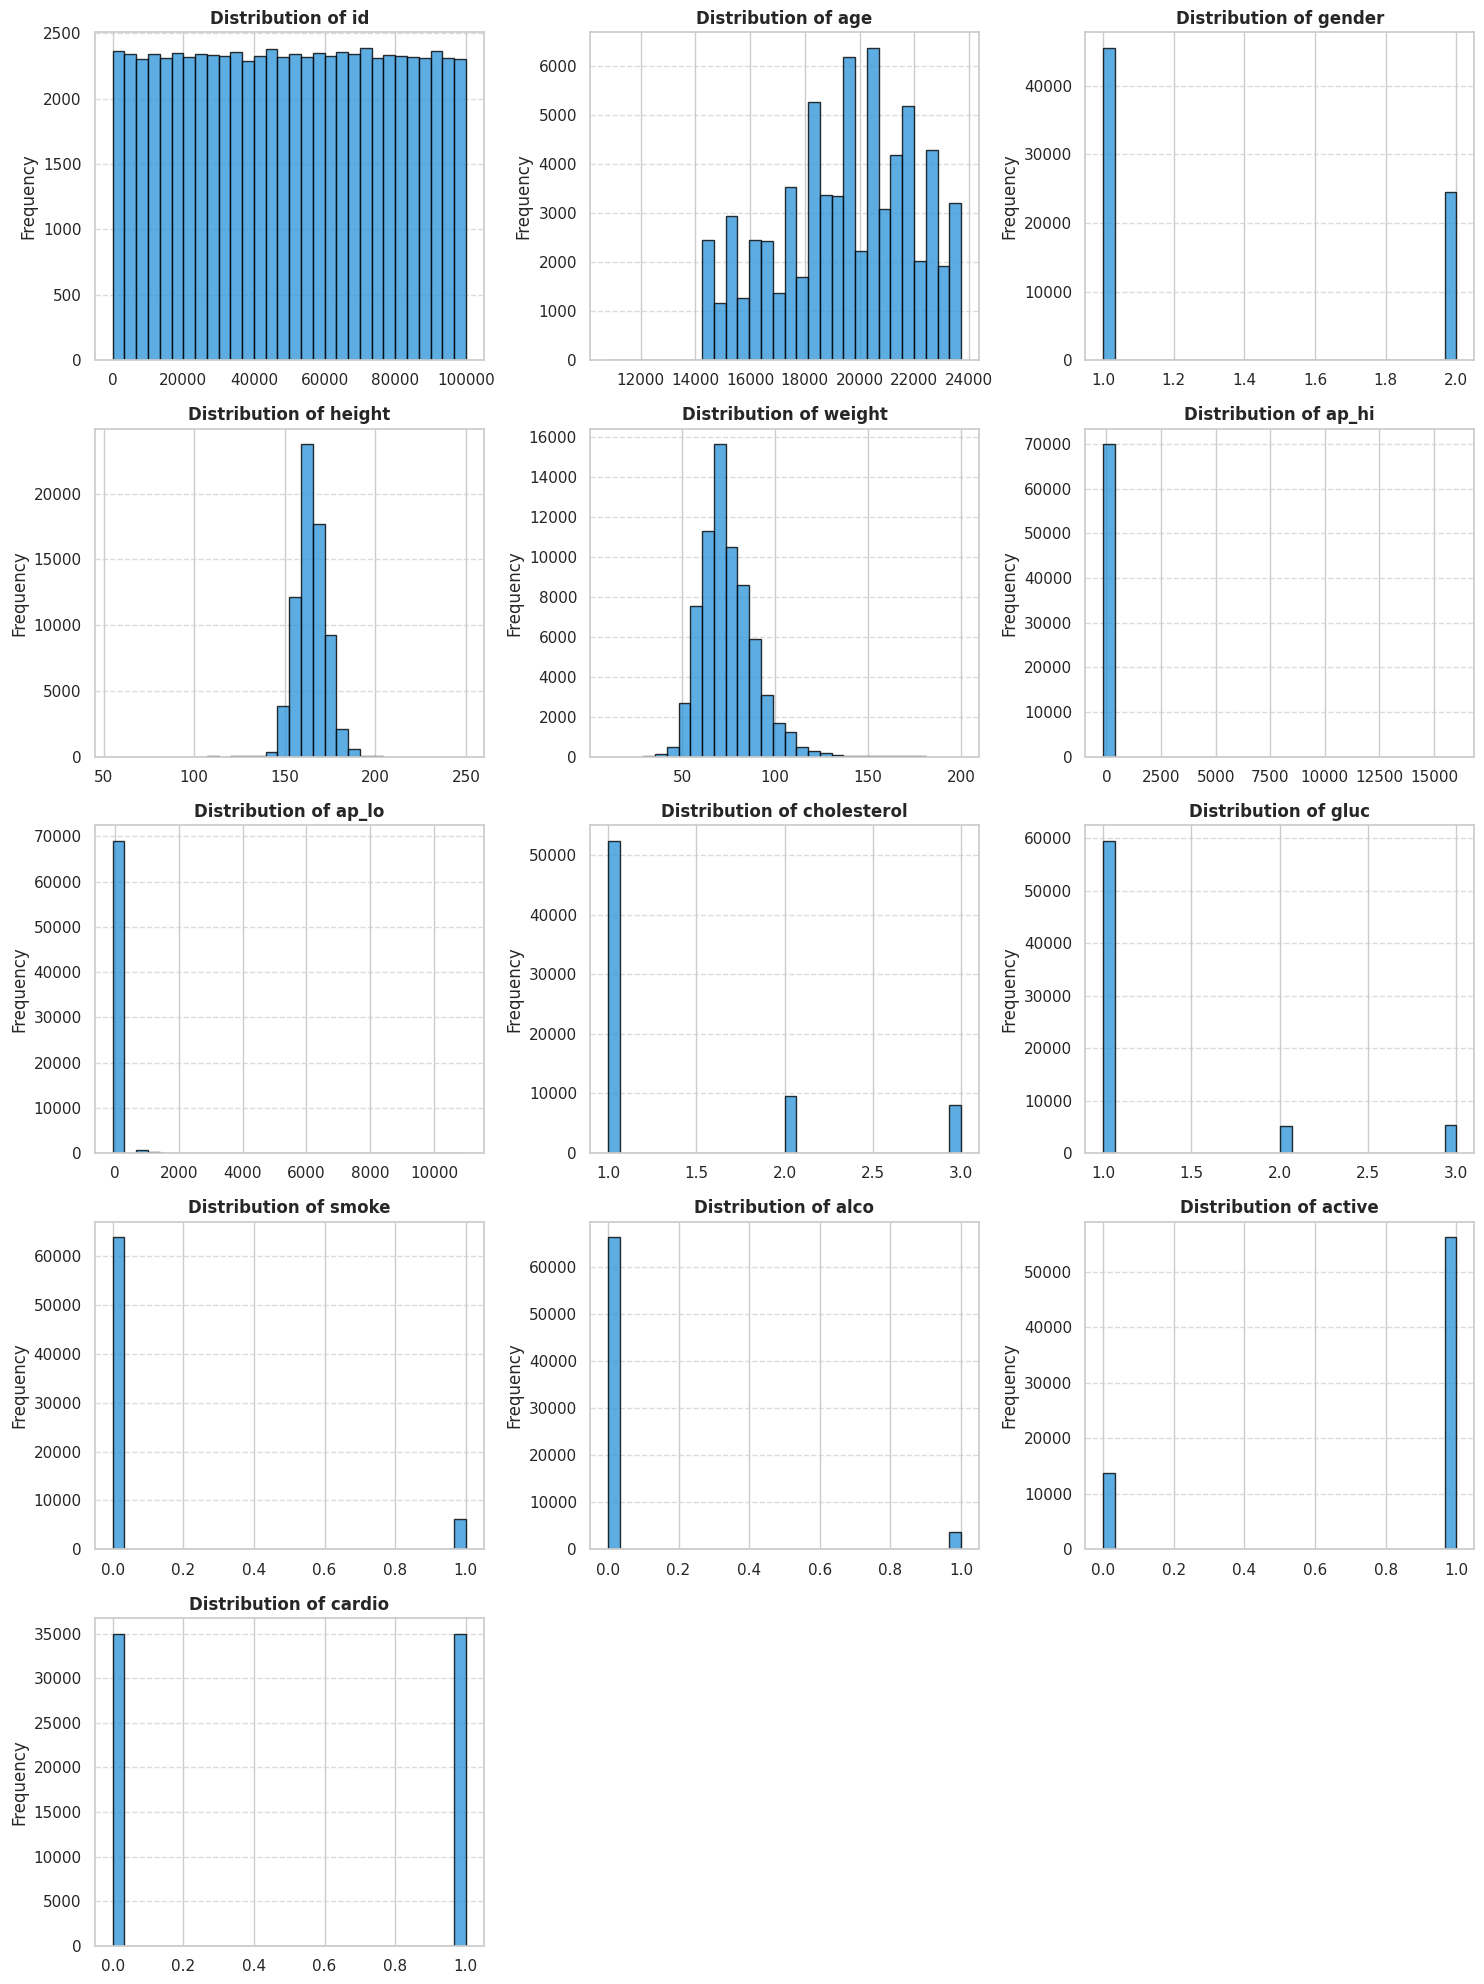

In [31]:
plot_distributions(df)

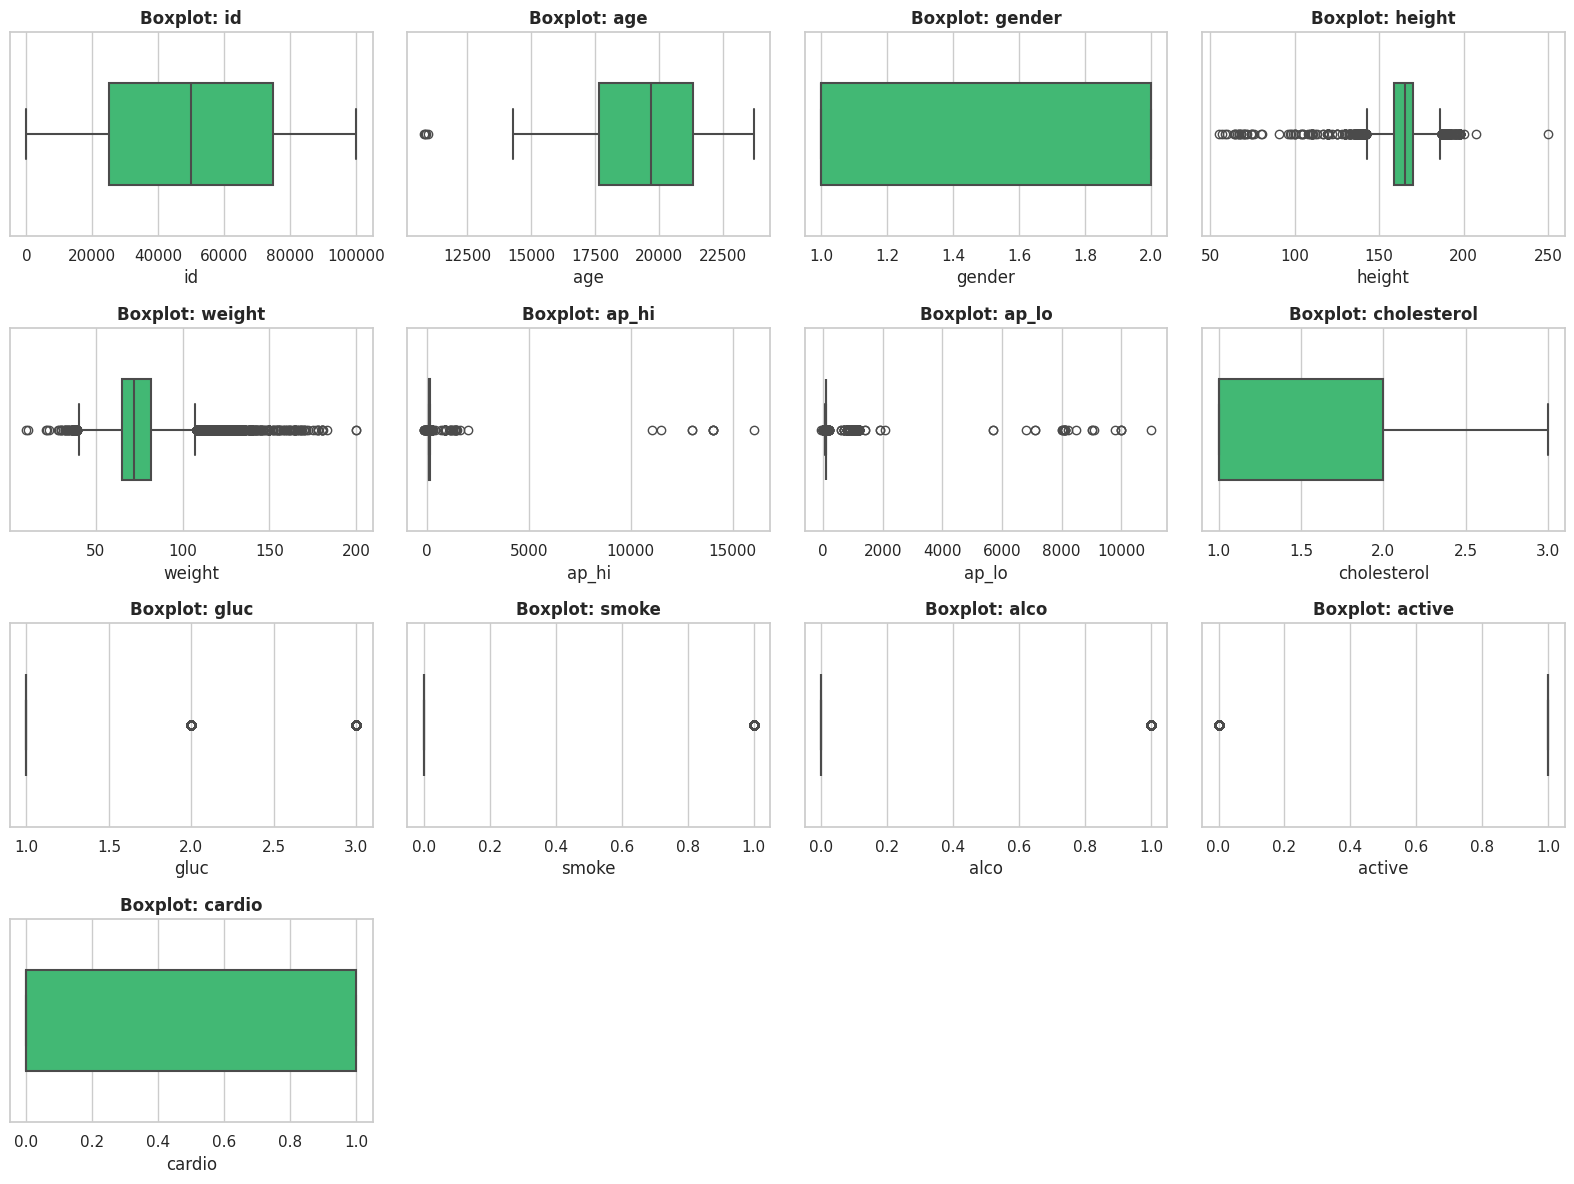

In [32]:
plot_outliers(df)

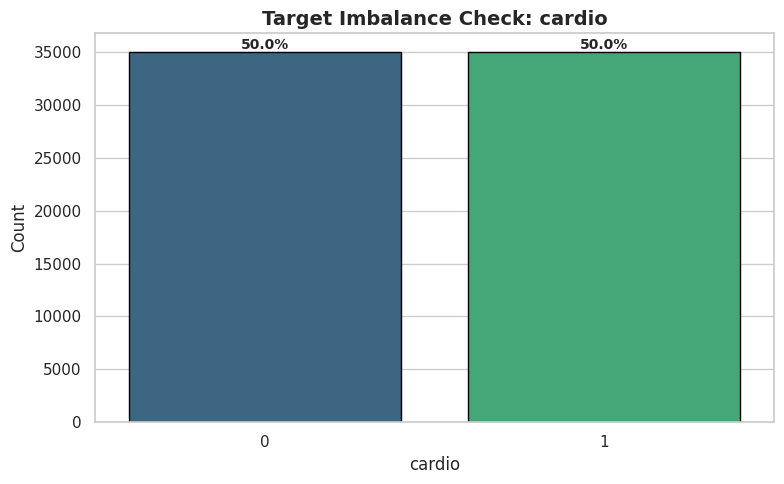

In [33]:
plot_target_distribution(df, "cardio")

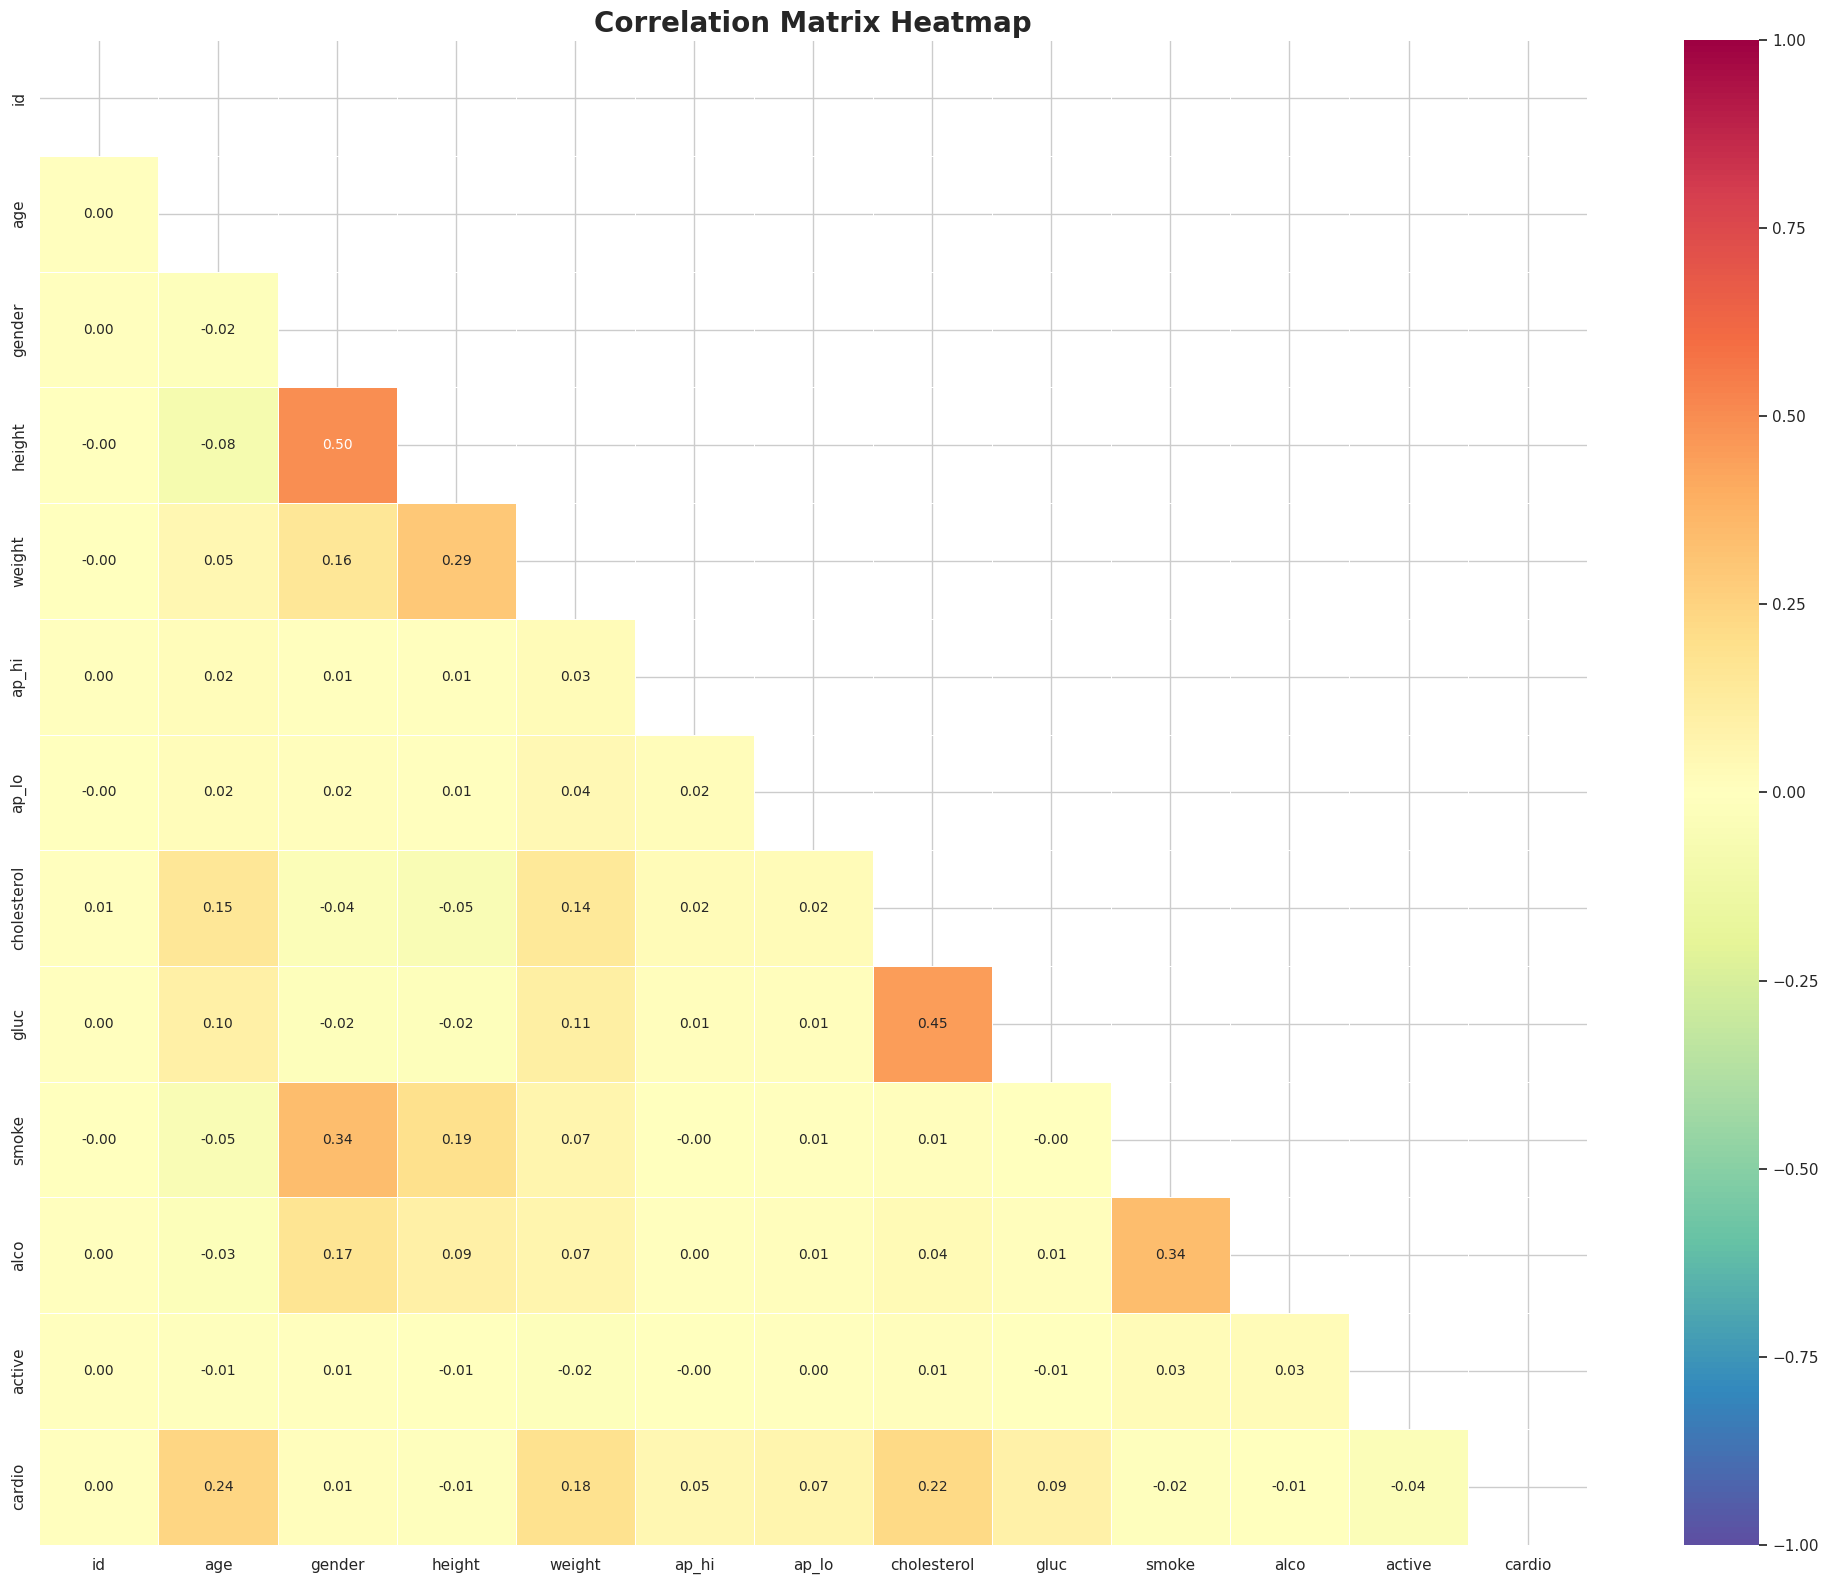

In [34]:
plot_correlation(df)

# 🔧 Data Preprocessing and Feature Engineering

## Drop ID

In [35]:
df.drop(columns=["id"],inplace=True)

## Convert Age To Years

In [36]:
df["age_in_years"] = (df["age"] / 365.25).round().astype(int)

In [37]:
df.drop(columns = ["age"], inplace=True)

## Calculate BMI

In [38]:
# Remove Impossible Values

df = df[(df['height'] >= 140) & (df['height'] <= 210)]
df = df[(df['weight'] >= 40) & (df['weight'] <= 175)]
df["BMI"] = df["weight"]/(((df["height"])/100)**2)
df = df[(df['BMI'] >= 15) & (df['BMI'] <= 60)]

In [39]:
df.drop(columns = ["weight","height"], inplace=True)

## Calculate Pulse Pressure and MAP

In [40]:
# Remove Impossible Values

df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]

df = df[(df['ap_lo'] >= 50) & (df['ap_lo'] <= 150)]

df = df[df['ap_hi'] > df['ap_lo']]

df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

df['map'] = ((2* df['ap_lo']) + df['ap_hi']) / 3

df = df[(df['pulse_pressure'] >= 20) & (df['pulse_pressure'] <= 120)]

df = df[(df['map'] >= 60) & (df['map'] <= 160)]

## Remove Duplicates without Target

In [41]:
duplicates_without_target = df.drop(columns=['cardio'])
contradictions = df[duplicates_without_target.duplicated(keep=False)]

print(f"Total overlapping profiles: {len(contradictions)}")

features_without_target = df.columns.drop('cardio')
df = df.drop_duplicates(subset=features_without_target, keep=False)

Total overlapping profiles: 8719


# 🏷️ Data Encoding

In [42]:
df['gender'] = df['gender'].map({1: 0, 2: 1})
df['cholesterol'] = df['cholesterol'] - 1
df['gluc'] = df['gluc'] - 1
print("Encoded Data Successfully!")

Encoded Data Successfully!


# 🔀 Data Splitting

In [43]:
X = df.drop(columns=['cardio', 'id'], errors='ignore')
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y       
)

print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

Training rows: 47674 | Testing rows: 11919


# ⚖️ Data Scaling

In [44]:
scaler = RobustScaler()

numerical_cols = [
    'age_in_years', 
    'BMI', 
    'pulse_pressure', 'map'
]

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
print("Scaled Data Successfully!")

Scaled Data Successfully!


# 🌟 Feature Importance 

Training models on 1 target(s)...
 -> Evaluating 'cardio' as CLASSIFICATION...


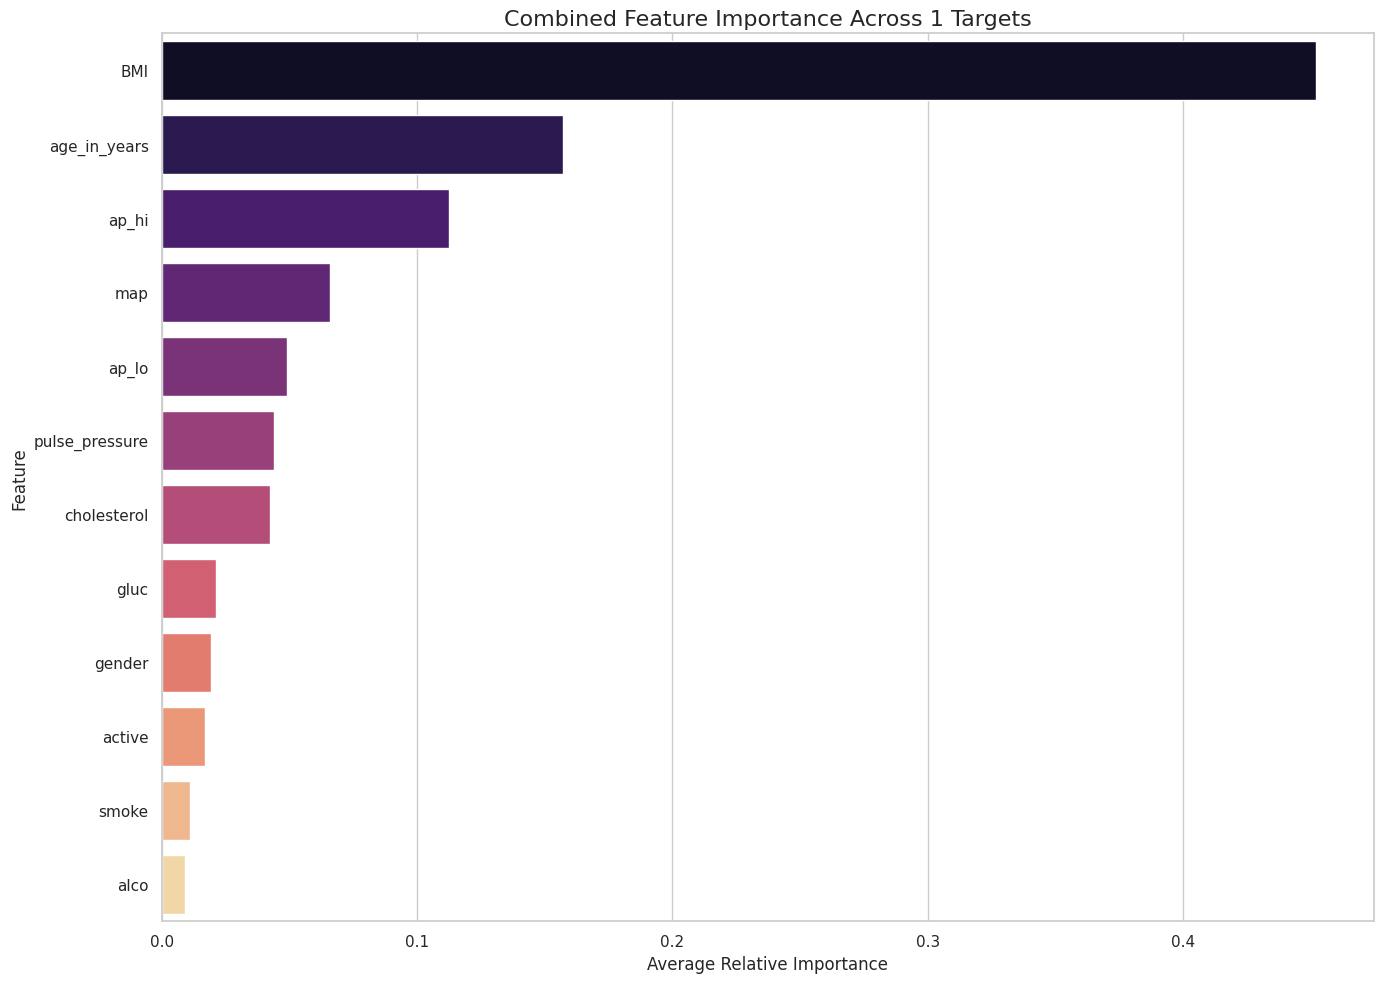

In [46]:
target = {
    'cardio': 'classification'
}
get_combined_feature_importance(X_train, y_train.to_frame(), target, n_estimators=100, max_depth=None, random_state=42)

# 🏗️ Model Archeticture

In [52]:
model = GradientBoostingClassifier(subsample= 0.9, n_estimators= 300, min_samples_split= 2, 
min_samples_leaf= 1, max_features= 'sqrt', max_depth= 5, loss= 'log_loss', learning_rate= 0.05, 
ccp_alpha= 0.0,random_state=42)

model.fit(X_train,y_train)
print("Model Training Completed!")

Model Training Completed!


# 🧪 Model Testing

In [53]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("Model Predictions Completed!")

Model Predictions Completed!


# 📊 Model Evaluation

## Classification Report & Confusion Matrix

📊 CLASSIFICATION REPORT
                        precision    recall  f1-score   support

               Healthy       0.72      0.74      0.73      5752
CardioVascular Disease       0.75      0.73      0.74      6167

              accuracy                           0.73     11919
             macro avg       0.73      0.73      0.73     11919
          weighted avg       0.74      0.73      0.73     11919

-------------------------------------------------------
Accuracy           : 0.7346
Weighted Precision : 0.7350
Weighted Recall    : 0.7346
Weighted F1-Score  : 0.7347


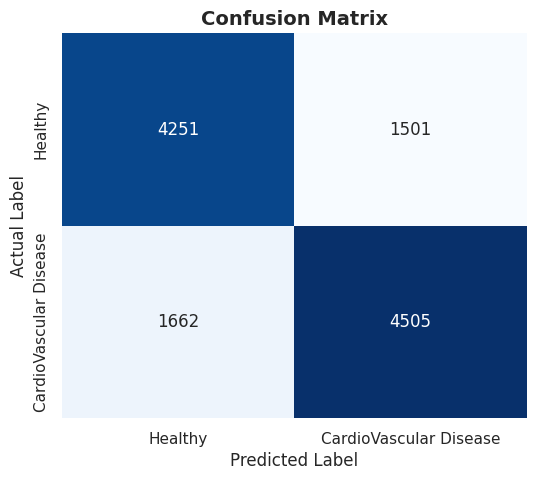

In [49]:
evaluate_classification(y_test, y_pred, class_names=["Healthy","CardioVascular Disease"])

## ROC-AUC Curve

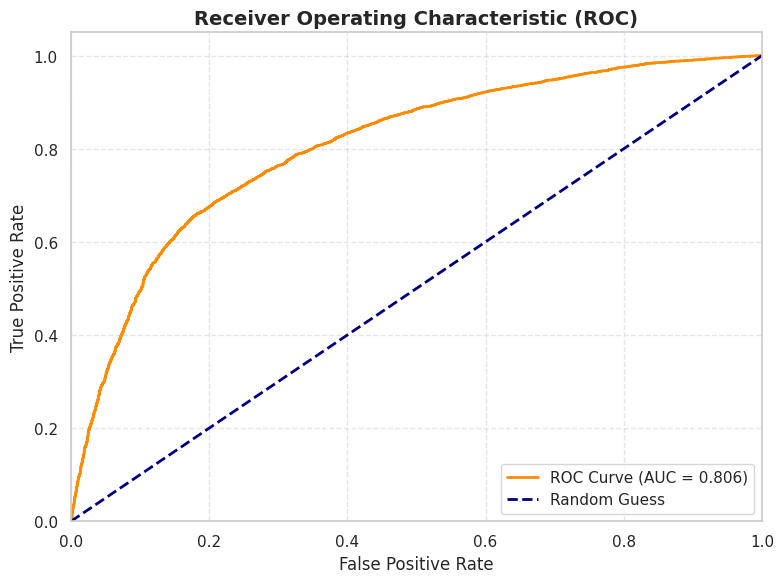

In [50]:
plot_roc_auc(y_test, y_proba, class_names=["Healthy","CardioVascular Disease"])

# 💾 Model Saving

In [54]:
export_for_deployment(model=model, preprocessor=scaler, model_name="aegis_model", preprocessor_name="aegis_model_scaler", is_dl_model=False)

📦 INITIATING DEPLOYMENT EXPORT 📦
✅ Preprocessor saved   : deployment_assets/aegis_model_scaler.joblib
   (Includes all Scalers, Encoders, and Dim Reduction states)
✅ Machine Learning saved: deployment_assets/aegis_model.joblib
